# TimeGPT – Foundation Model für Kraftstoffpreis-Prognose

**Nixtla TimeGPT auf wöchentlichen Kraftstoffpreisen (2020–2026) | Deutschland, Frankreich, Indonesien**

---

## Inhaltsverzeichnis

1. [Setup & Daten](#setup)
2. [Basis-Prognose (Forecasting at Scale)](#forecast)
3. [Uncertainty Quantification](#uncertainty)
4. [Exogenous Variables](#exogenous)
5. [Cross-Validation](#cv)
6. [Fine-Tuning](#finetune)
7. [Improve Accuracy – Fine-Tuning vs. Basis](#improve)
8. [Anomaly Detection](#anomaly)
9. [Zusammenfassung](#fazit)
10. [Business Scenario Forecasting](#business)

<a id='setup'></a>
## 1. Setup & Daten

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nixtla import NixtlaClient
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# API-Key hier einfuegen
# ============================================================
TIMEGPT_API_KEY = "...# ============================================================

nixtla_client = NixtlaClient(api_key=TIMEGPT_API_KEY)
nixtla_client.validate_api_key()

PLOT_DIR = Path('../docs/plots_aus_timegpt')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

FORECAST_HORIZON = 8
COUNTRIES = ['Germany', 'France', 'Indonesia']
COUNTRY_LABELS = {'Germany': 'Deutschland', 'France': 'Frankreich', 'Indonesia': 'Indonesien'}

print('Setup abgeschlossen.')

INFO:nixtla.nixtla_client:Happy Forecasting! :)


Setup abgeschlossen.


In [7]:
DATA_DIR = Path('../data/processed')

raw_data = {}
frames = []
for country in COUNTRIES:
    df = pd.read_csv(DATA_DIR / f'fuel_prices_{country}.csv', parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    raw_data[country] = df

    ts = pd.DataFrame({
        'unique_id': country,
        'ds': df['date'],
        'y': df['petrol_usd_liter']
    })
    frames.append(ts)

df_all = pd.concat(frames, ignore_index=True)

# Train/Test Split
# keep the grouping index as a column so `unique_id` remains present
# build train/test by iterating groups to ensure `unique_id` is preserved
train_parts = []
test_parts = []
for uid, g in df_all.groupby('unique_id'):
    g = g.sort_values('ds').reset_index(drop=True)
    train_parts.append(g.iloc[:-FORECAST_HORIZON].assign(unique_id=uid))
    test_parts.append(g.iloc[-FORECAST_HORIZON:].assign(unique_id=uid))

df_train = pd.concat(train_parts, ignore_index=True)
df_test = pd.concat(test_parts, ignore_index=True)

print(f'Gesamt: {len(df_all)} Zeilen | Train: {len(df_train)} | Test: {len(df_test)}')
print(f'Laender: {df_all["unique_id"].unique().tolist()}')
print(f'Forecast-Horizont: {FORECAST_HORIZON} Wochen')
df_all.head()

Gesamt: 981 Zeilen | Train: 957 | Test: 24
Laender: ['Germany', 'France', 'Indonesia']
Forecast-Horizont: 8 Wochen


,unique_id,ds,y
0,Germany,2020-01-06,2.600
1,Germany,2020-01-13,2.581
2,Germany,2020-01-20,2.653
3,Germany,2020-01-27,2.678
4,Germany,2020-02-03,2.676


In [8]:
# Diagnose & Auto-Fill: ensure weekly timestamps per unique_id (W-MON)
def _ensure_weekly_and_fill(df_all, id_col='unique_id', time_col='ds', target_col='y', freq='W-MON', fill_method='ffill'):
    reports = []
    parts = []
    for uid, grp in df_all.groupby(id_col):
        g = grp.copy()
        g[time_col] = pd.to_datetime(g[time_col])
        g = g.sort_values(time_col)
        # drop exact duplicate timestamps, keep first
        dup_ts = g[time_col][g[time_col].duplicated(keep=False)]
        n_dups = dup_ts.nunique() if len(dup_ts) > 0 else 0

        # target index from first to last at requested freq
        idx = pd.date_range(start=g[time_col].min(), end=g[time_col].max(), freq=freq)
        missing = sorted(set(idx) - set(g[time_col]))

        # reindex and fill
        g = g.drop_duplicates(subset=time_col).set_index(time_col)
        idx = pd.DatetimeIndex(idx, name=time_col)
        g = g.reindex(idx)
        # ensure target numeric
        if target_col in g.columns:
            g[target_col] = pd.to_numeric(g[target_col], errors='coerce')
            if fill_method == 'ffill':
                g[target_col] = g[target_col].ffill()
            else:
                g[target_col] = g[target_col].interpolate(limit_direction='both')

        g = g.reset_index()
        g[id_col] = uid
        parts.append(g)
        reports.append({'unique_id': uid, 'n_obs_before': len(grp), 'n_obs_after': len(g), 'n_missing_filled': len(missing), 'n_duplicate_ts': int(n_dups)})

    return pd.concat(parts, ignore_index=True), pd.DataFrame(reports)

print('Running frequency check and auto-fill for weekly (W-MON) series...')
df_all_fixed, fix_report = _ensure_weekly_and_fill(df_all, id_col='unique_id', time_col='ds', target_col='y', freq='W-MON', fill_method='ffill')
display(fix_report)

# Recreate train/test splits from the fixed full dataframe
# preserve `unique_id` when reconstructing grouped frames
# build train/test from fixed dataframe and preserve `unique_id`
train_parts = []
test_parts = []
for uid, g in df_all_fixed.groupby('unique_id'):
    g = g.sort_values('ds').reset_index(drop=True)
    train_parts.append(g.iloc[:-FORECAST_HORIZON].assign(unique_id=uid))
    test_parts.append(g.iloc[-FORECAST_HORIZON:].assign(unique_id=uid))

df_train = pd.concat(train_parts, ignore_index=True)
df_test = pd.concat(test_parts, ignore_index=True)

print(f'Nach Auto-Fill: Gesamt: {len(df_all_fixed)} Zeilen | Train: {len(df_train)} | Test: {len(df_test)}')

Running frequency check and auto-fill for weekly (W-MON) series...


,unique_id,n_obs_before,n_obs_after,n_missing_filled,n_duplicate_ts
0,France,327,327,0,0
1,Germany,327,327,0,0
2,Indonesia,327,327,0,0


Nach Auto-Fill: Gesamt: 981 Zeilen | Train: 957 | Test: 24


<a id='forecast'></a>
## 2. Basis-Prognose (Forecasting at Scale)

TimeGPT prognostiziert **alle drei Länder gleichzeitig** – Zero-Shot, ohne Training. Das `unique_id`-Feld teilt dem Modell mit, welche Zeilen zusammengehören.

In [9]:
fcst_base = nixtla_client.forecast(
    df=df_train,
    h=FORECAST_HORIZON,
    freq='W-MON'
)

print(f'Prognose: {len(fcst_base)} Zeilen ({len(fcst_base) // FORECAST_HORIZON} Laender x {FORECAST_HORIZON} Wochen)')
fcst_base.head(12)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Prognose: 24 Zeilen (3 Laender x 8 Wochen)


,unique_id,ds,TimeGPT
0,France,2026-02-16,4.660566
1,France,2026-02-23,4.668041
2,France,2026-03-02,4.664621
3,France,2026-03-09,4.654612
4,France,2026-03-16,4.652182
5,France,2026-03-23,4.647389
6,France,2026-03-30,4.627048
7,France,2026-04-06,4.640449
8,Germany,2026-02-16,4.740589
9,Germany,2026-02-23,4.747916


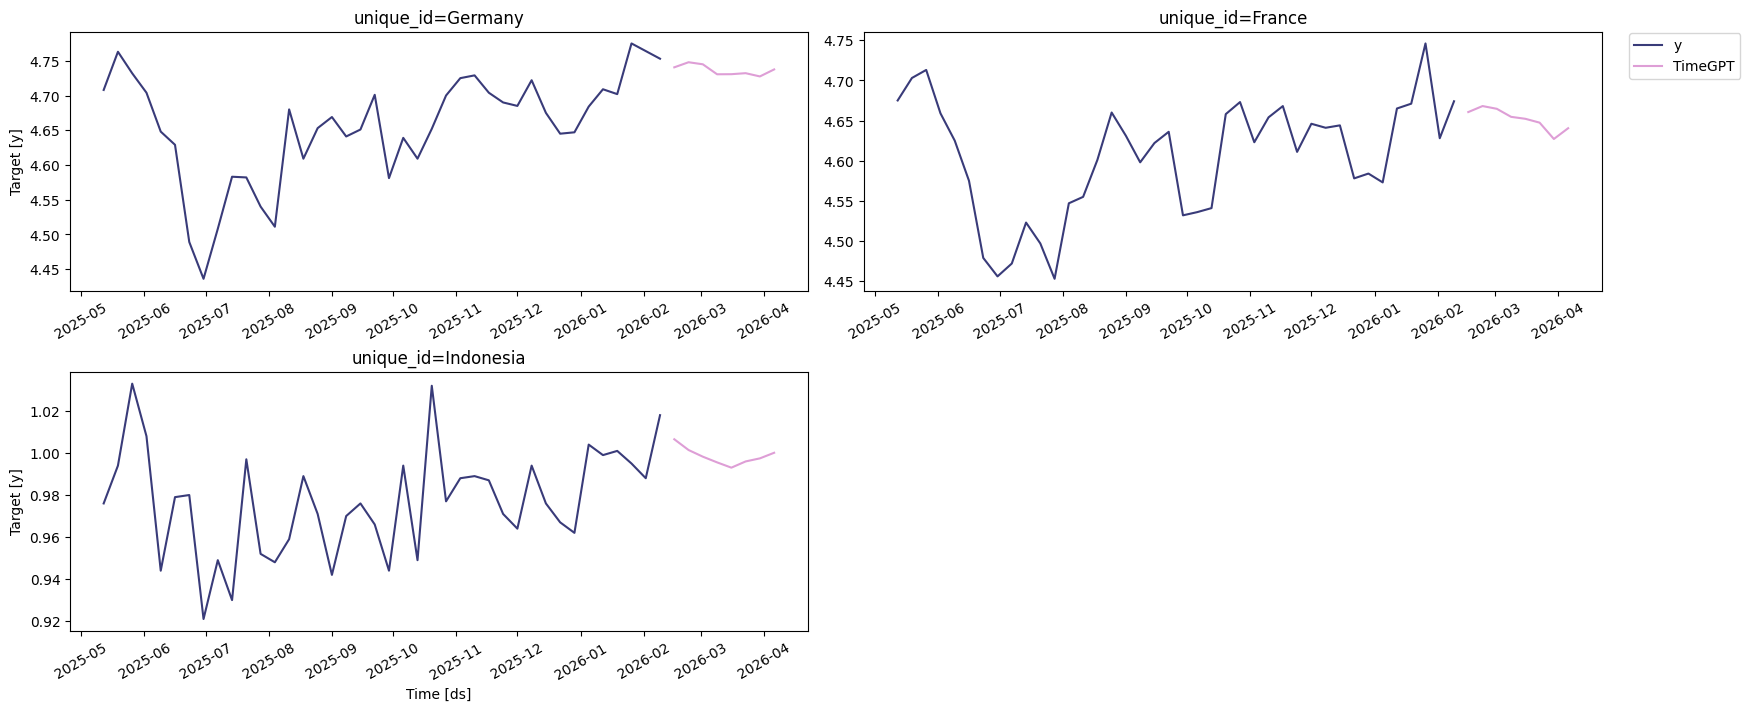

In [10]:
nixtla_client.plot(
    df_train.groupby('unique_id').tail(40),
    fcst_base,
    unique_ids=['Germany', 'France', 'Indonesia'],
    max_insample_length=40
)

In [11]:
def evaluate_timegpt(forecast_df, test_df, model_name='TimeGPT'):
    results = []
    for country in COUNTRIES:
        actual = test_df[test_df['unique_id'] == country]['y'].values
        pred_col = [c for c in forecast_df.columns if 'TimeGPT' in c and 'lo' not in c and 'hi' not in c][0]
        predicted = forecast_df[forecast_df['unique_id'] == country][pred_col].values
        n = min(len(actual), len(predicted))
        actual, predicted = actual[:n], predicted[:n]
        results.append({
            'Land': COUNTRY_LABELS[country],
            'Modell': model_name,
            'RMSE': round(np.sqrt(mean_squared_error(actual, predicted)), 4),
            'MAE': round(mean_absolute_error(actual, predicted), 4),
            'MAPE (%)': round(mean_absolute_percentage_error(actual, predicted) * 100, 2)
        })
    return pd.DataFrame(results)

base_results = evaluate_timegpt(fcst_base, df_test, 'TimeGPT Basis')
print('=== Basis-Prognose (ohne Fine-Tuning) ===')
display(base_results)

=== Basis-Prognose (ohne Fine-Tuning) ===


,Land,Modell,RMSE,MAE,MAPE (%)
0,Deutschland,TimeGPT Basis,0.3270,0.2865,5.61
1,Frankreich,TimeGPT Basis,0.3528,0.3010,5.95
2,Indonesien,TimeGPT Basis,0.0668,0.0603,5.69


<a id='uncertainty'></a>
## 3. Uncertainty Quantification

Der `level`-Parameter erzeugt **Konfidenzintervalle**: Wie sicher ist sich das Modell? Ein `level=[80, 95]` bedeutet: 80% und 95% der zukünftigen Werte sollten innerhalb der Bänder liegen.

In [12]:
fcst_intervals = nixtla_client.forecast(
    df=df_train,
    h=FORECAST_HORIZON,
    freq='W-MON',
    level=[80, 95]
)

print('Spalten mit Konfidenzintervallen:')
print(fcst_intervals.columns.tolist())
fcst_intervals.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Spalten mit Konfidenzintervallen:
['unique_id', 'ds', 'TimeGPT', 'TimeGPT-hi-80', 'TimeGPT-hi-95', 'TimeGPT-lo-80', 'TimeGPT-lo-95']


,unique_id,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-95,TimeGPT-lo-80,TimeGPT-lo-95
0,France,2026-02-16,4.660566,4.722819,4.726781,4.598313,4.594351
1,France,2026-02-23,4.668041,4.711966,4.721125,4.624116,4.614957
2,France,2026-03-02,4.664621,4.729224,4.735054,4.600019,4.594189
3,France,2026-03-09,4.654612,4.707382,4.715534,4.601843,4.593691
4,France,2026-03-16,4.652182,4.693676,4.699751,4.610688,4.604613


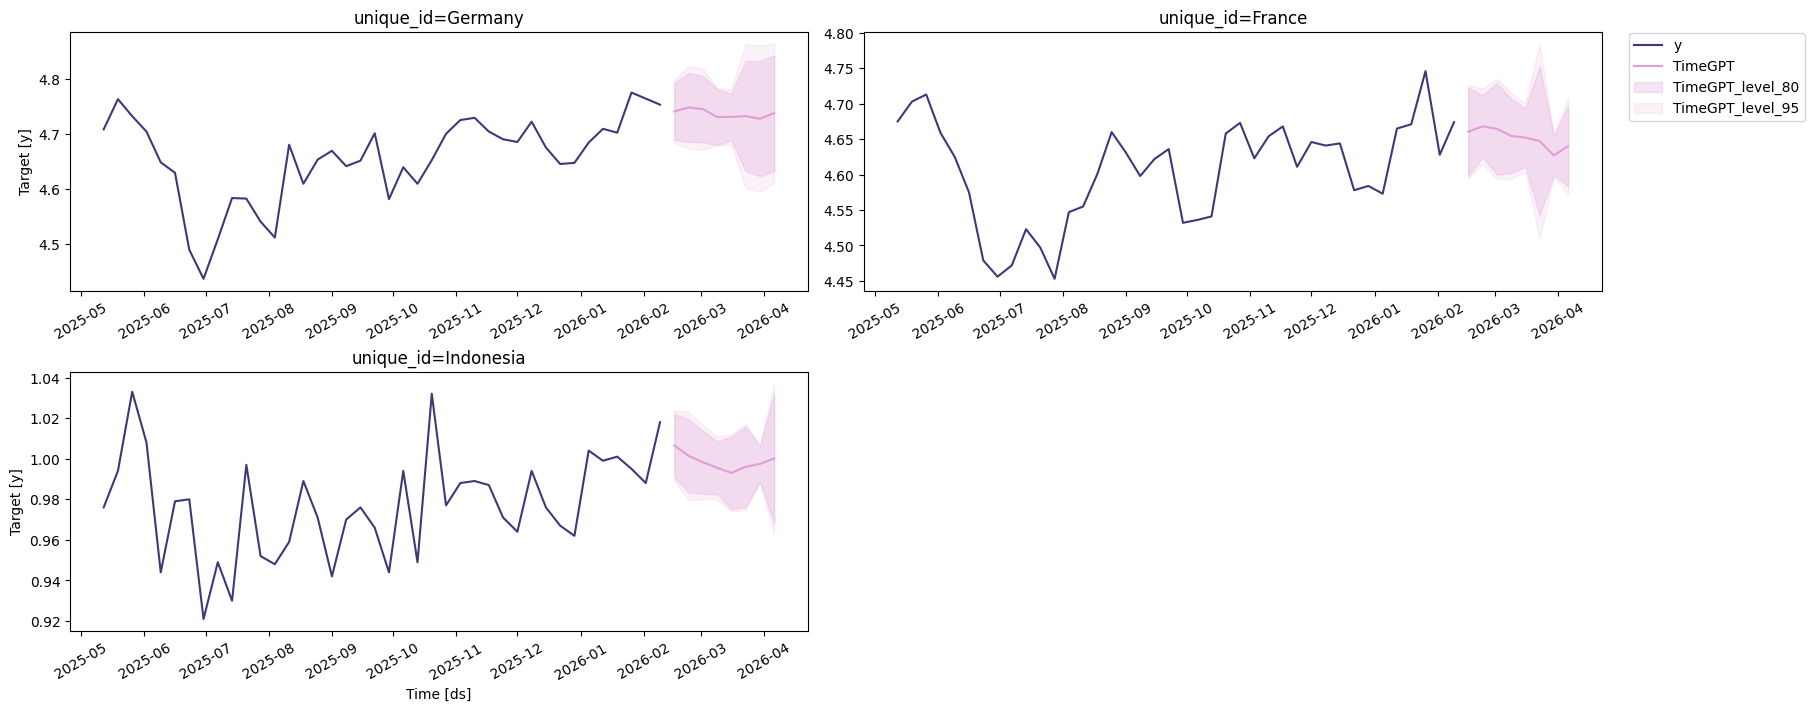

In [13]:
nixtla_client.plot(
    df_train.groupby('unique_id').tail(40),
    fcst_intervals,
    unique_ids=['Germany', 'France', 'Indonesia'],
    level=[80, 95],
    max_insample_length=40
)

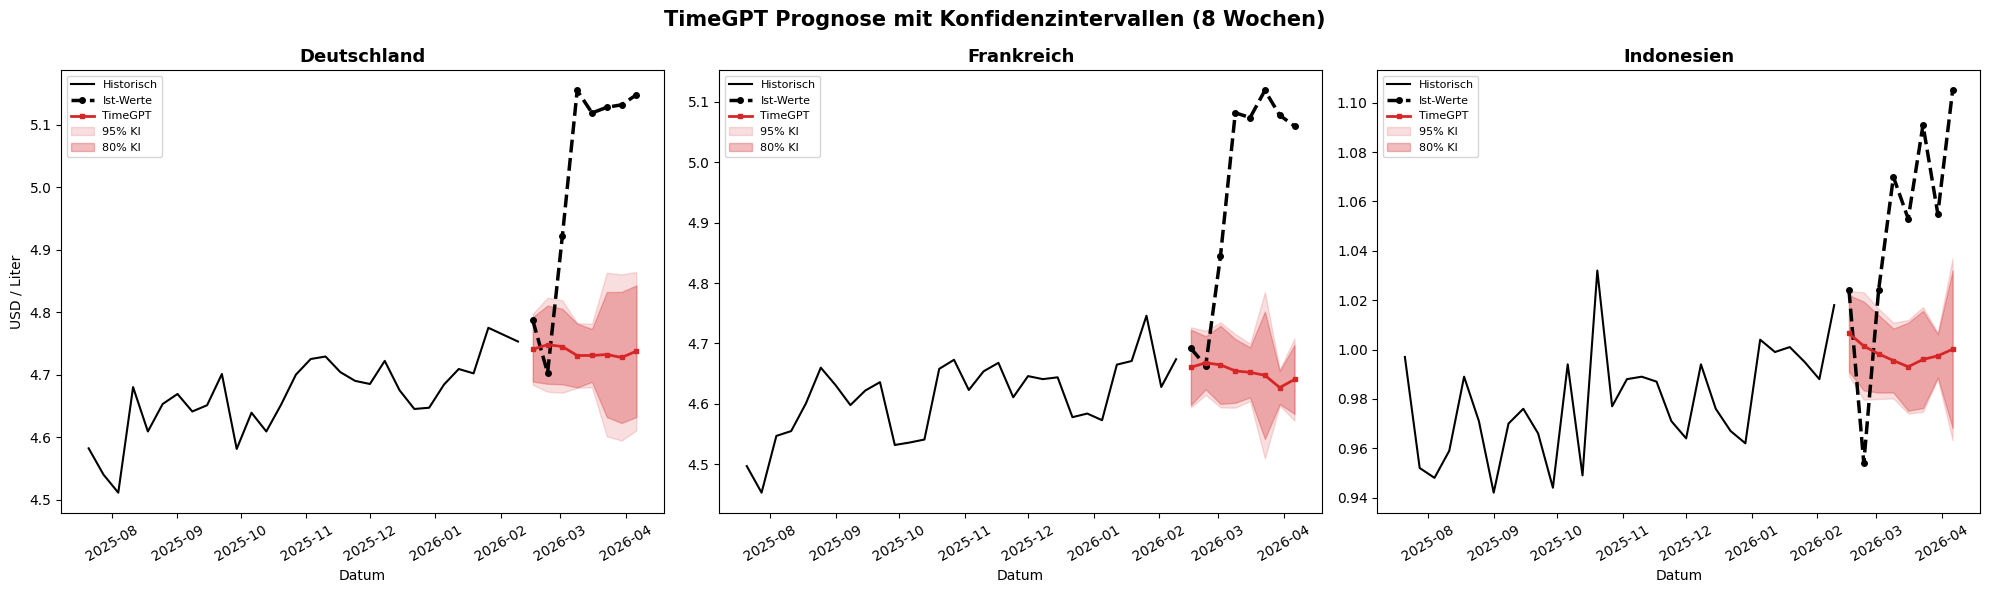

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    cf = fcst_intervals[fcst_intervals['unique_id'] == country]
    hist = df_train[df_train['unique_id'] == country].tail(30)
    test = df_test[df_test['unique_id'] == country]

    ax.plot(hist['ds'], hist['y'], color='black', linewidth=1.5, label='Historisch')
    ax.plot(test['ds'].values, test['y'].values, color='black', linewidth=2.5,
            linestyle='--', marker='o', markersize=4, label='Ist-Werte')
    ax.plot(cf['ds'].values, cf['TimeGPT'].values, color='#d62728',
            linewidth=2, marker='s', markersize=3, label='TimeGPT')
    ax.fill_between(cf['ds'].values, cf['TimeGPT-lo-95'].values,
                    cf['TimeGPT-hi-95'].values, alpha=0.15, color='#d62728', label='95% KI')
    ax.fill_between(cf['ds'].values, cf['TimeGPT-lo-80'].values,
                    cf['TimeGPT-hi-80'].values, alpha=0.3, color='#d62728', label='80% KI')
    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('Datum')
    if i == 0:
        ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('TimeGPT Prognose mit Konfidenzintervallen (8 Wochen)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '01_timegpt_konfidenzintervalle.png')
plt.show()

**Beobachtung:** Die Konfidenzbänder für Indonesien sind deutlich schmaler als für Europa – das Modell erkennt die geringere Volatilität des subventionierten Markts automatisch.

<a id='exogenous'></a>
## 4. Exogenous Variables

Kann TimeGPT besser prognostizieren, wenn wir **zusätzliche Informationen** mitgeben? Wir fügen Brent-Rohölpreis und Dieselpreis als exogene Variablen hinzu.

**Wichtig:** Für exogene Variablen brauchen wir auch die **zukünftigen Werte** (`X_df`) – das Modell muss wissen, wie sich die exogenen Variablen im Prognosezeitraum entwickeln.

In [15]:
frames_exog = []
for country in COUNTRIES:
    rd = raw_data[country]
    ts = pd.DataFrame({
        'unique_id': country,
        'ds': rd['date'],
        'y': rd['petrol_usd_liter'],
        'brent_crude_usd': rd['brent_crude_usd'],
        'diesel_usd_liter': rd['diesel_usd_liter']
    })
    frames_exog.append(ts)

df_exog = pd.concat(frames_exog, ignore_index=True)

# build df_exog_train and X_future while preserving unique_id
exog_train_parts = []
X_future_parts = []
for uid, g in df_exog.groupby('unique_id'):
    g = g.sort_values('ds').reset_index(drop=True)
    exog_train_parts.append(g.iloc[:-FORECAST_HORIZON].assign(unique_id=uid))
    X_future_parts.append(g.iloc[-FORECAST_HORIZON:].assign(unique_id=uid))

df_exog_train = pd.concat(exog_train_parts, ignore_index=True)
X_future = pd.concat(X_future_parts, ignore_index=True).drop(columns=['y'])

print(f'Train mit Exogenen: {df_exog_train.shape}')
print(f'Spalten: {df_exog_train.columns.tolist()}')
print(f'\nFuture Exogene: {X_future.shape}')
X_future.head()

Train mit Exogenen: (957, 5)
Spalten: ['unique_id', 'ds', 'y', 'brent_crude_usd', 'diesel_usd_liter']

Future Exogene: (24, 4)


,unique_id,ds,brent_crude_usd,diesel_usd_liter
0,France,2026-02-16,120.67,4.646
1,France,2026-02-23,119.62,4.610
2,France,2026-03-02,124.85,4.810
3,France,2026-03-09,130.00,4.948
4,France,2026-03-16,130.00,4.987


In [16]:
fcst_exog = nixtla_client.forecast(
    df=df_exog_train,
    X_df=X_future,
    h=FORECAST_HORIZON,
    freq='W-MON',
    level=[80, 95]
)

exog_results = evaluate_timegpt(fcst_exog, df_test, 'TimeGPT + Exogene')
print('=== Prognose mit exogenen Variablen (Brent, Diesel) ===')
display(exog_results)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['brent_crude_usd', 'diesel_usd_liter']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


=== Prognose mit exogenen Variablen (Brent, Diesel) ===


,Land,Modell,RMSE,MAE,MAPE (%)
0,Deutschland,TimeGPT + Exogene,0.0190,0.0155,0.31
1,Frankreich,TimeGPT + Exogene,0.0245,0.0183,0.37
2,Indonesien,TimeGPT + Exogene,0.0233,0.0202,1.96


In [17]:
compare_exog = pd.merge(
    base_results[['Land', 'RMSE', 'MAPE (%)']].rename(columns={'RMSE': 'RMSE Basis', 'MAPE (%)': 'MAPE Basis'}),
    exog_results[['Land', 'RMSE', 'MAPE (%)']].rename(columns={'RMSE': 'RMSE + Exogene', 'MAPE (%)': 'MAPE + Exogene'}),
    on='Land'
)
compare_exog['RMSE Verbesserung'] = compare_exog.apply(
    lambda r: f"{'besser' if r['RMSE + Exogene'] < r['RMSE Basis'] else 'schlechter'} "
              f"({(r['RMSE Basis'] - r['RMSE + Exogene']) / r['RMSE Basis'] * 100:+.1f}%)", axis=1
)
print('=== Basis vs. Exogene Variablen ===')
display(compare_exog)

=== Basis vs. Exogene Variablen ===


,Land,RMSE Basis,MAPE Basis,RMSE + Exogene,MAPE + Exogene,RMSE Verbesserung
0,Deutschland,0.3270,5.61,0.0190,0.31,besser (+94.2%)
1,Frankreich,0.3528,5.95,0.0245,0.37,besser (+93.1%)
2,Indonesien,0.0668,5.69,0.0233,1.96,besser (+65.1%)


<a id='cv'></a>
## 5. Cross-Validation

Wie robust sind die Ergebnisse? Cross-Validation erstellt **mehrere Trainings-/Testfenster** und evaluiert das Modell auf jedem. Das gibt ein ehrlicheres Bild als ein einzelner Train/Test-Split.

In [18]:
cv_results = nixtla_client.cross_validation(
    df=df_all,
    h=FORECAST_HORIZON,
    n_windows=3,
    freq='W-MON',
    level=[80]
)

print(f'Cross-Validation: {len(cv_results)} Zeilen')
print(f'Fenster (cutoffs): {cv_results["cutoff"].nunique()}')
print(f'Cutoff-Daten:')
for c in sorted(cv_results['cutoff'].unique()):
    print(f'  {c}')
cv_results.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Cross Validation Endpoint...


Cross-Validation: 72 Zeilen
Fenster (cutoffs): 3
Cutoff-Daten:
  2025-10-20 00:00:00
  2025-12-15 00:00:00
  2026-02-09 00:00:00


,unique_id,ds,cutoff,y,TimeGPT,TimeGPT-hi-80,TimeGPT-lo-80
0,France,2025-10-27,2025-10-20,4.673,4.623072,4.641333,4.604811
1,France,2025-11-03,2025-10-20,4.623,4.607569,4.622977,4.592161
2,France,2025-11-10,2025-10-20,4.654,4.607535,4.648263,4.566807
3,France,2025-11-17,2025-10-20,4.668,4.604362,4.677403,4.531321
4,France,2025-11-24,2025-10-20,4.611,4.633595,4.672873,4.594317


In [19]:
cv_metrics = []
for country in COUNTRIES:
    for cutoff in cv_results['cutoff'].unique():
        mask = (cv_results['unique_id'] == country) & (cv_results['cutoff'] == cutoff)
        subset = cv_results[mask]
        if len(subset) == 0:
            continue
        actual = subset['y'].values
        predicted = subset['TimeGPT'].values
        cv_metrics.append({
            'Land': COUNTRY_LABELS[country],
            'Cutoff': str(cutoff)[:10],
            'RMSE': round(np.sqrt(mean_squared_error(actual, predicted)), 4),
            'MAE': round(mean_absolute_error(actual, predicted), 4),
            'MAPE (%)': round(mean_absolute_percentage_error(actual, predicted) * 100, 2)
        })

cv_df = pd.DataFrame(cv_metrics)
print('=== Cross-Validation Ergebnisse pro Fenster ===')
display(cv_df)

print('\n=== Durchschnitt ueber alle Fenster ===')
display(cv_df.groupby('Land')[['RMSE', 'MAE', 'MAPE (%)']].mean().round(4))

=== Cross-Validation Ergebnisse pro Fenster ===


,Land,Cutoff,RMSE,MAE,MAPE (%)
0,Deutschland,2025-10-20,0.0505,0.0428,0.91
1,Deutschland,2025-12-15,0.0907,0.0750,1.58
2,Deutschland,2026-02-09,0.3270,0.2865,5.61
3,Frankreich,2025-10-20,0.0361,0.0307,0.66
4,Frankreich,2025-12-15,0.0744,0.0655,1.41
5,Frankreich,2026-02-09,0.3528,0.3010,5.95
6,Indonesien,2025-10-20,0.0124,0.0111,1.14
7,Indonesien,2025-12-15,0.0214,0.0198,1.99
8,Indonesien,2026-02-09,0.0668,0.0603,5.69



=== Durchschnitt ueber alle Fenster ===


,RMSE,MAE,MAPE (%)
Land,,,
Deutschland,0.1561,0.1348,2.7000
Frankreich,0.1544,0.1324,2.6733
Indonesien,0.0335,0.0304,2.9400


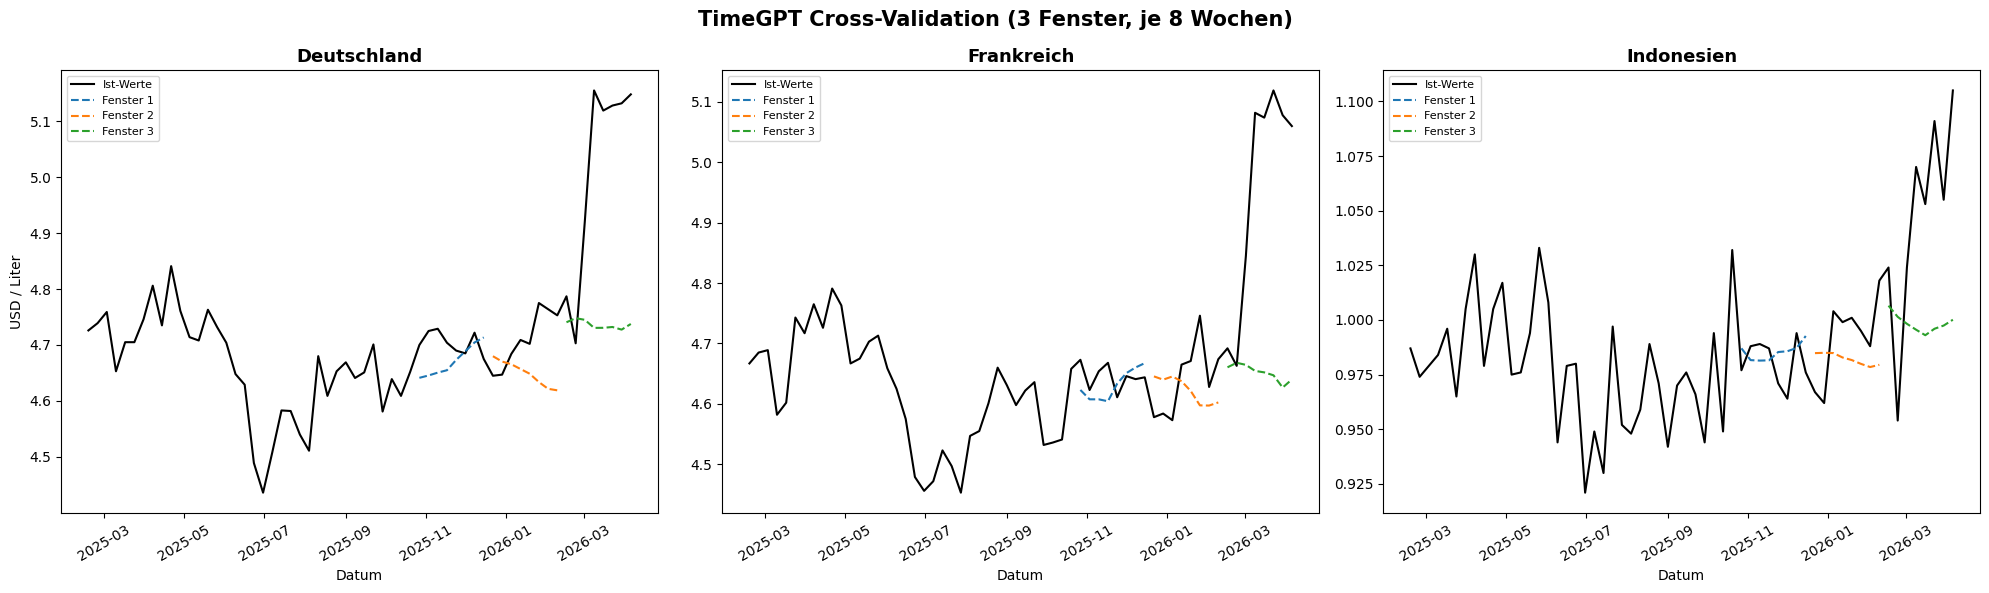

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
cutoffs = sorted(cv_results['cutoff'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    hist = df_all[df_all['unique_id'] == country].tail(60)
    ax.plot(hist['ds'], hist['y'], color='black', linewidth=1.5, label='Ist-Werte')

    for j, cutoff in enumerate(cutoffs):
        mask = (cv_results['unique_id'] == country) & (cv_results['cutoff'] == cutoff)
        subset = cv_results[mask]
        ax.plot(subset['ds'].values, subset['TimeGPT'].values,
                linestyle='--', color=colors[j % len(colors)],
                linewidth=1.5, label=f'Fenster {j+1}')

    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('Datum')
    if i == 0:
        ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('TimeGPT Cross-Validation (3 Fenster, je 8 Wochen)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_timegpt_crossvalidation.png')
plt.show()

<a id='finetune'></a>
## 6. Fine-Tuning

TimeGPT ist vortrainiert auf Millionen von Zeitreihen. Mit `finetune_steps` passen wir das Modell **zusätzlich auf unsere spezifischen Daten** an. Das ist wie ein Sprachmodell, das erst allgemein trainiert und dann auf eine Fachdomäne feinabgestimmt wird.

In [21]:
fcst_finetuned = nixtla_client.forecast(
    df=df_train,
    h=FORECAST_HORIZON,
    freq='W-MON',
    finetune_steps=10,
    level=[80, 95]
)

ft_results = evaluate_timegpt(fcst_finetuned, df_test, 'TimeGPT Fine-Tuned (10)')
print('=== Fine-Tuned Prognose (10 Steps) ===')
display(ft_results)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


=== Fine-Tuned Prognose (10 Steps) ===


,Land,Modell,RMSE,MAE,MAPE (%)
0,Deutschland,TimeGPT Fine-Tuned (10),0.3305,0.2893,5.67
1,Frankreich,TimeGPT Fine-Tuned (10),0.3528,0.3008,5.95
2,Indonesien,TimeGPT Fine-Tuned (10),0.0670,0.0604,5.70


In [22]:
fcst_finetuned_50 = nixtla_client.forecast(
    df=df_train,
    h=FORECAST_HORIZON,
    freq='W-MON',
    finetune_steps=50,
    level=[80, 95]
)

ft50_results = evaluate_timegpt(fcst_finetuned_50, df_test, 'TimeGPT Fine-Tuned (50)')
print('=== Fine-Tuned Prognose (50 Steps) ===')
display(ft50_results)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


=== Fine-Tuned Prognose (50 Steps) ===


,Land,Modell,RMSE,MAE,MAPE (%)
0,Deutschland,TimeGPT Fine-Tuned (50),0.3057,0.2678,5.25
1,Frankreich,TimeGPT Fine-Tuned (50),0.3354,0.2858,5.65
2,Indonesien,TimeGPT Fine-Tuned (50),0.0615,0.0550,5.20


<a id='improve'></a>
## 7. Improve Accuracy – Gesamtvergleich

Welche TimeGPT-Variante funktioniert am besten für unsere Kraftstoffpreise?

In [23]:
all_timegpt_results = pd.concat([
    base_results,
    exog_results,
    ft_results,
    ft50_results
], ignore_index=True)

print('=== Gesamtvergleich aller TimeGPT-Varianten ===')
display(all_timegpt_results.sort_values(['Land', 'RMSE']))

=== Gesamtvergleich aller TimeGPT-Varianten ===


,Land,Modell,RMSE,MAE,MAPE (%)
3,Deutschland,TimeGPT + Exogene,0.0190,0.0155,0.31
9,Deutschland,TimeGPT Fine-Tuned (50),0.3057,0.2678,5.25
0,Deutschland,TimeGPT Basis,0.3270,0.2865,5.61
6,Deutschland,TimeGPT Fine-Tuned (10),0.3305,0.2893,5.67
4,Frankreich,TimeGPT + Exogene,0.0245,0.0183,0.37
10,Frankreich,TimeGPT Fine-Tuned (50),0.3354,0.2858,5.65
1,Frankreich,TimeGPT Basis,0.3528,0.3010,5.95
7,Frankreich,TimeGPT Fine-Tuned (10),0.3528,0.3008,5.95
5,Indonesien,TimeGPT + Exogene,0.0233,0.0202,1.96
11,Indonesien,TimeGPT Fine-Tuned (50),0.0615,0.0550,5.20


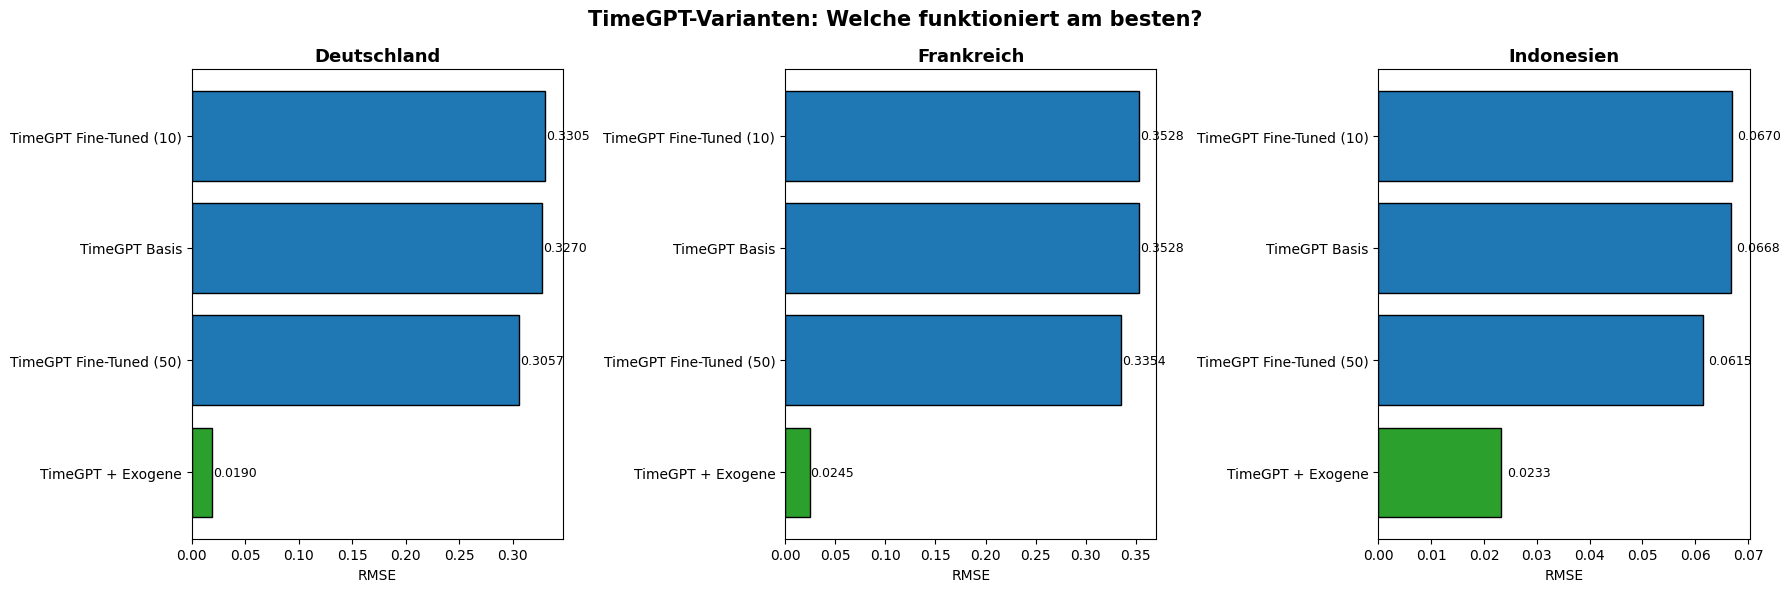

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models = all_timegpt_results['Modell'].unique()
model_colors = ['#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    cdata = all_timegpt_results[all_timegpt_results['Land'] == COUNTRY_LABELS[country]].sort_values('RMSE')
    colors = ['#2ca02c' if v == cdata['RMSE'].min() else '#1f77b4' for v in cdata['RMSE']]
    bars = ax.barh(cdata['Modell'], cdata['RMSE'], color=colors, edgecolor='black')
    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('RMSE')
    for bar, val in zip(bars, cdata['RMSE']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

fig.suptitle('TimeGPT-Varianten: Welche funktioniert am besten?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_timegpt_varianten_vergleich.png')
plt.show()

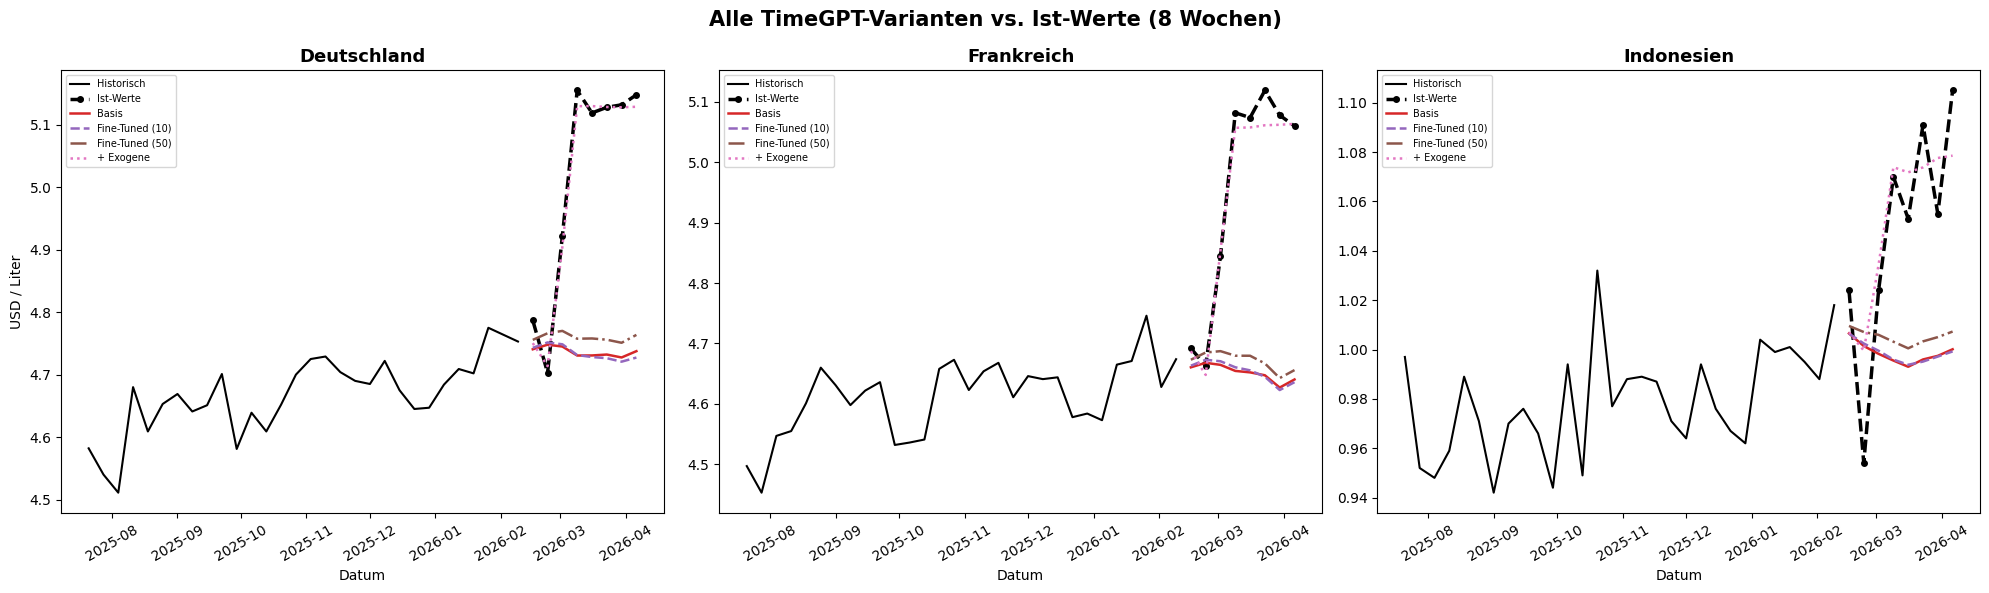

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

forecast_map = {
    'Basis': fcst_base,
    'Fine-Tuned (10)': fcst_finetuned,
    'Fine-Tuned (50)': fcst_finetuned_50,
    '+ Exogene': fcst_exog
}
fc_colors = {'Basis': '#d62728', 'Fine-Tuned (10)': '#9467bd',
             'Fine-Tuned (50)': '#8c564b', '+ Exogene': '#e377c2'}
fc_styles = {'Basis': '-', 'Fine-Tuned (10)': '--', 'Fine-Tuned (50)': '-.', '+ Exogene': ':'}

for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    hist = df_train[df_train['unique_id'] == country].tail(30)
    test = df_test[df_test['unique_id'] == country]
    ax.plot(hist['ds'], hist['y'], color='black', linewidth=1.5, label='Historisch')
    ax.plot(test['ds'].values, test['y'].values, color='black', linewidth=2.5,
            linestyle='--', marker='o', markersize=4, label='Ist-Werte')

    for name, fc_df in forecast_map.items():
        fc = fc_df[fc_df['unique_id'] == country]
        pred_col = [c for c in fc.columns if 'TimeGPT' in c and 'lo' not in c and 'hi' not in c][0]
        ax.plot(fc['ds'].values, fc[pred_col].values,
                linestyle=fc_styles[name], color=fc_colors[name],
                linewidth=1.8, label=name)

    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('Datum')
    if i == 0:
        ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=7, loc='best')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Alle TimeGPT-Varianten vs. Ist-Werte (8 Wochen)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '04_timegpt_alle_varianten.png')
plt.show()

<a id='anomaly'></a>
## 8. Anomaly Detection

TimeGPT kann auch **Anomalien** erkennen – Zeitpunkte, an denen sich die Preise ungewöhnlich verhalten. Das Modell lernt das "normale" Muster und markiert Abweichungen.

**Erwartung:** In Europa sollten Anomalien während der Ukraine-Krise 2022 auftauchen. In Indonesien eher bei seltenen Subventionsanpassungen.

In [26]:
anomalies = nixtla_client.detect_anomalies(
    df=df_all,
    freq='W-MON'
)

print(f'Gefundene Anomalien: {anomalies["anomaly"].sum()} von {len(anomalies)} Datenpunkten')
print(f'\nAnomalien pro Land:')
for country in COUNTRIES:
    n = anomalies[anomalies['unique_id'] == country]['anomaly'].sum()
    print(f'  {COUNTRY_LABELS[country]}: {n} Anomalien')

anomalies[anomalies['anomaly'] == True].head(10)

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Calling Anomaly Detector Endpoint...


Gefundene Anomalien: 15 von 792 Datenpunkten

Anomalien pro Land:
  Deutschland: 5 Anomalien
  Frankreich: 5 Anomalien
  Indonesien: 5 Anomalien


,unique_id,ds,y,TimeGPT,TimeGPT-hi-99,TimeGPT-lo-99,anomaly
4,France,2021-04-19,4.016,3.510401,4.011297,3.009505,True
5,France,2021-04-26,3.976,3.452628,3.953524,2.951731,True
6,France,2021-05-03,4.019,3.428155,3.929051,2.927258,True
7,France,2021-05-10,4.017,3.468376,3.969272,2.967480,True
79,France,2022-09-26,4.276,4.812349,5.313245,4.311453,True
268,Germany,2021-04-19,4.085,3.561600,4.068976,3.054223,True
269,Germany,2021-04-26,4.034,3.510166,4.017542,3.002790,True
270,Germany,2021-05-03,4.053,3.483442,3.990818,2.976065,True
271,Germany,2021-05-10,4.094,3.518557,4.025933,3.011180,True
343,Germany,2022-09-26,4.348,4.856973,5.364349,4.349596,True


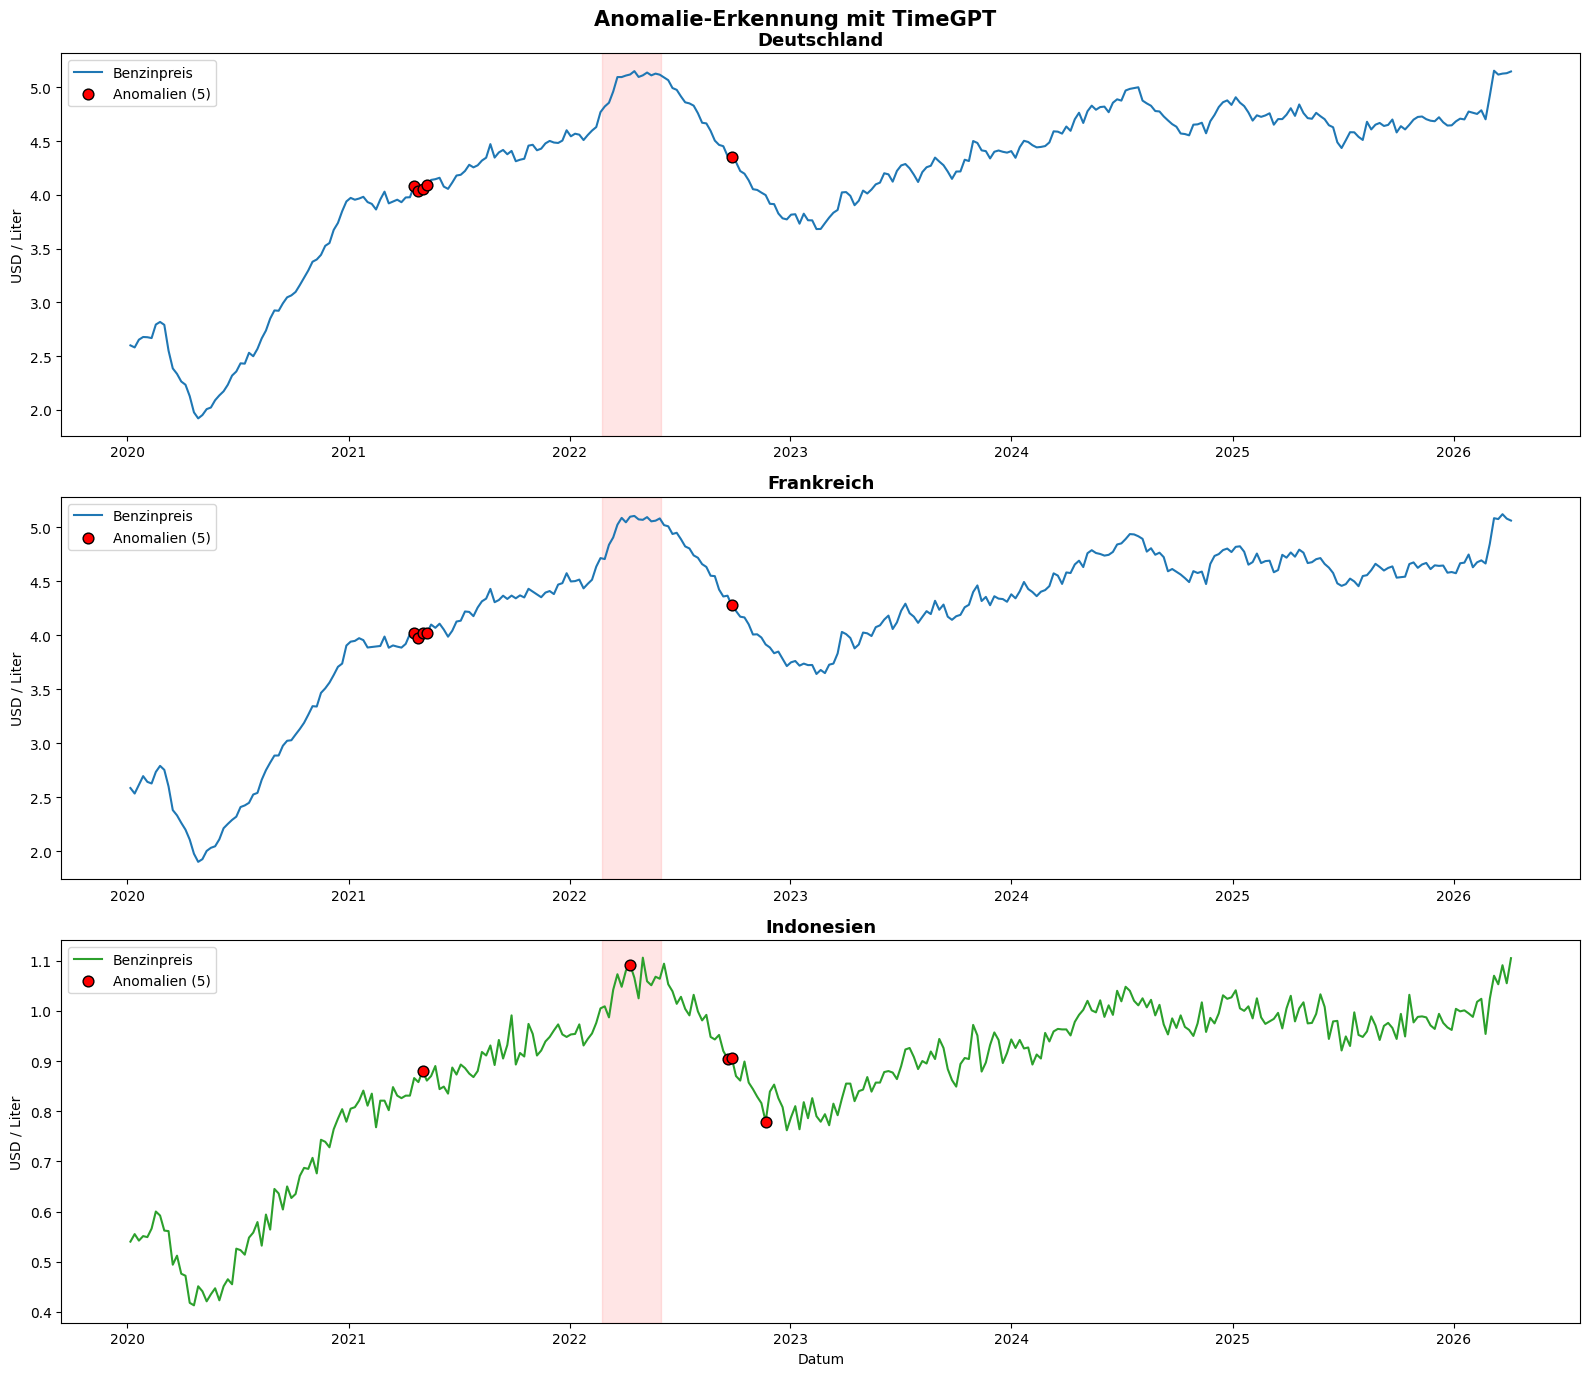

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    country_data = df_all[df_all['unique_id'] == country]
    country_anom = anomalies[(anomalies['unique_id'] == country) & (anomalies['anomaly'] == True)]

    ax.plot(country_data['ds'], country_data['y'],
            color=('#1f77b4' if country != 'Indonesia' else '#2ca02c'),
            linewidth=1.5, label='Benzinpreis')

    if len(country_anom) > 0:
        anom_dates = country_anom['ds'].values
        anom_vals = country_data[country_data['ds'].isin(anom_dates)]['y'].values
        if len(anom_vals) == len(anom_dates):
            ax.scatter(anom_dates, anom_vals, color='red', s=60, zorder=5,
                       label=f'Anomalien ({len(country_anom)})', edgecolors='black')

    ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-01'),
               alpha=0.1, color='red')
    ax.set_title(f'{COUNTRY_LABELS[country]}', fontsize=13, fontweight='bold')
    ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=10)

axes[2].set_xlabel('Datum')
fig.suptitle('Anomalie-Erkennung mit TimeGPT', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_timegpt_anomalien.png')
plt.show()

<a id='fazit'></a>
## 9. Zusammenfassung

### Was haben wir gelernt?

| Feature | Ergebnis |
|---------|----------|
| **Forecasting at Scale** | TimeGPT prognostiziert alle 3 Länder gleichzeitig ohne separates Training |
| **Uncertainty Quantification** | Konfidenzintervalle passen sich automatisch an die Volatilität an (breiter für Europa, schmaler für Indonesien) |
| **Exogenous Variables** | Brent und Diesel als exogene Variablen können die Prognose verbessern |
| **Cross-Validation** | Ergebnisse sind über mehrere Zeitfenster hinweg stabil |
| **Fine-Tuning** | Anpassung an domänenspezifische Muster möglich – Effekt variiert je nach Marktregime |
| **Anomaly Detection** | Erkennt automatisch ungewöhnliche Preisbewegungen (z.B. Ukraine-Krise) |

In [29]:
print('=== Finale Ergebnisuebersicht ===')
display(all_timegpt_results.sort_values(['Land', 'RMSE']))

print('\n=== Exportierte Grafiken ===')
for f in sorted(PLOT_DIR.glob('*.png')):
    print(f'  {f.name}')
print(f'\nInsgesamt: {len(list(PLOT_DIR.glob("*.png")))} Grafiken exportiert.')

=== Finale Ergebnisuebersicht ===


,Land,Modell,RMSE,MAE,MAPE (%)
3,Deutschland,TimeGPT + Exogene,0.0190,0.0155,0.31
9,Deutschland,TimeGPT Fine-Tuned (50),0.3057,0.2678,5.25
0,Deutschland,TimeGPT Basis,0.3270,0.2865,5.61
6,Deutschland,TimeGPT Fine-Tuned (10),0.3305,0.2893,5.67
4,Frankreich,TimeGPT + Exogene,0.0245,0.0183,0.37
10,Frankreich,TimeGPT Fine-Tuned (50),0.3354,0.2858,5.65
1,Frankreich,TimeGPT Basis,0.3528,0.3010,5.95
7,Frankreich,TimeGPT Fine-Tuned (10),0.3528,0.3008,5.95
5,Indonesien,TimeGPT + Exogene,0.0233,0.0202,1.96
11,Indonesien,TimeGPT Fine-Tuned (50),0.0615,0.0550,5.20



=== Exportierte Grafiken ===
  01_timegpt_konfidenzintervalle.png
  02_timegpt_crossvalidation.png
  03_timegpt_varianten_vergleich.png
  04_timegpt_alle_varianten.png
  05_timegpt_anomalien.png

Insgesamt: 5 Grafiken exportiert.


---

<a id='business'></a>
## 10. Business Scenario Forecasting

### Von Modellevaluation zur Zukunftsprognose

Alle bisherigen Abschnitte haben Modelle **gegen bekannte Vergangenheit** getestet (Backtesting). Jetzt drehen wir den Schalter um:

**Wir trainieren auf ALLEN verfügbaren Daten und prognostizieren 12 Wochen in die echte Zukunft** – Sommer 2026.

Zwei Modelle treten an:
- **TimeGPT Basis** – Zero-Shot, ohne Zusatzinformationen
- **TimeGPT Fine-Tuned (50) + Exogene** – feinabgestimmt auf unsere Domäne, mit Brent, Diesel und Steuerquote als Szenario-Inputs

Für die exogenen Variablen erstellen wir ein **realistisches Szenario** basierend auf den letzten bekannten Marktdaten.

In [31]:
# ============================================================
# Business Scenario Forecasting – Setup
# ============================================================

BUSINESS_PLOT_DIR = Path('../docs/business_forecasts')
BUSINESS_PLOT_DIR.mkdir(parents=True, exist_ok=True)

BUSINESS_HORIZON = 12  # 12 Wochen in die Zukunft (Sommer 2026)

# Alle Daten für Training verwenden – kein Test-Split
frames_full = []
for country in COUNTRIES:
    rd = raw_data[country]
    ts = pd.DataFrame({
        'unique_id': country,
        'ds': rd['date'],
        'y': rd['petrol_usd_liter']
    })
    frames_full.append(ts)

df_full = pd.concat(frames_full, ignore_index=True)

print(f'Training auf ALLEN Daten: {len(df_full)} Zeilen')
print(f'Letzter Datenpunkt: {df_full["ds"].max().date()}')
print(f'Prognose-Horizont: {BUSINESS_HORIZON} Wochen')
print(f'Prognose bis: {(df_full["ds"].max() + pd.Timedelta(weeks=BUSINESS_HORIZON)).date()}')


Training auf ALLEN Daten: 981 Zeilen
Letzter Datenpunkt: 2026-04-06
Prognose-Horizont: 12 Wochen
Prognose bis: 2026-06-29


### Szenario-Definition: Exogene Variablen für Sommer 2026

Da wir in die **echte Zukunft** prognostizieren, müssen wir Annahmen über die exogenen Variablen treffen. Wir verwenden ein **Status-Quo-Szenario**: Die letzten bekannten Werte werden mit leichtem Trend fortgeschrieben.

| Variable | Annahme |
|----------|---------|
| **Brent-Rohöl** | Leichter Rückgang von 130 auf ~120 USD (saisonale Entspannung) |
| **Diesel** | Folgt dem Brent-Trend mit länderspezifischem Aufschlag |
| **Steuerquote** | Konstant (keine Steueränderungen erwartet) |

In [32]:
# ============================================================
# Zukunfts-Szenario für exogene Variablen erstellen
# ============================================================

last_date = df_full['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(weeks=1),
                             periods=BUSINESS_HORIZON, freq='W-MON')

# Brent-Szenario: leichter Rückgang von 130 auf ~120 USD
brent_scenario = np.linspace(128, 120, BUSINESS_HORIZON)

# Exogene Trainingsdaten (alle Daten)
frames_exog_full = []
for country in COUNTRIES:
    rd = raw_data[country]
    ts = pd.DataFrame({
        'unique_id': country,
        'ds': rd['date'],
        'y': rd['petrol_usd_liter'],
        'brent_crude_usd': rd['brent_crude_usd'],
        'diesel_usd_liter': rd['diesel_usd_liter'],
        'tax_percentage': rd['tax_percentage']
    })
    frames_exog_full.append(ts)

df_exog_full = pd.concat(frames_exog_full, ignore_index=True)

# Zukunfts-Exogene pro Land
X_future_parts = []
for country in COUNTRIES:
    rd = raw_data[country]
    last_diesel = rd['diesel_usd_liter'].iloc[-1]
    last_tax = rd['tax_percentage'].iloc[-1]
    last_brent = rd['brent_crude_usd'].iloc[-1]

    # Diesel folgt Brent proportional
    diesel_ratio = last_diesel / last_brent
    diesel_scenario = brent_scenario * diesel_ratio

    future_df = pd.DataFrame({
        'unique_id': country,
        'ds': future_dates,
        'brent_crude_usd': brent_scenario,
        'diesel_usd_liter': diesel_scenario,
        'tax_percentage': last_tax
    })
    X_future_parts.append(future_df)

X_business = pd.concat(X_future_parts, ignore_index=True)

print('=== Zukunfts-Szenario (Status Quo) ===')
print(f'Zeitraum: {future_dates[0].date()} bis {future_dates[-1].date()}')
print(f'\nBrent-Prognose: {brent_scenario[0]:.0f} → {brent_scenario[-1]:.0f} USD')
print(f'\nExogene pro Land:')
for country in COUNTRIES:
    sub = X_business[X_business['unique_id'] == country]
    print(f'  {COUNTRY_LABELS[country]}: Diesel {sub["diesel_usd_liter"].iloc[0]:.2f}→{sub["diesel_usd_liter"].iloc[-1]:.2f}, '
          f'Steuer {sub["tax_percentage"].iloc[0]:.1f}%')

=== Zukunfts-Szenario (Status Quo) ===
Zeitraum: 2026-04-13 bis 2026-06-29

Brent-Prognose: 128 → 120 USD

Exogene pro Land:
  Deutschland: Diesel 4.76→4.46, Steuer 58.1%
  Frankreich: Diesel 4.90→4.59, Steuer 37.6%
  Indonesien: Diesel 0.99→0.93, Steuer 14.8%


### Prognose: Basis vs. Fine-Tuned + Exogene

In [33]:
# ============================================================
# Modell 1: TimeGPT Basis (Zero-Shot)
# ============================================================

fcst_business_basis = nixtla_client.forecast(
    df=df_full,
    h=BUSINESS_HORIZON,
    freq='W-MON',
    level=[80, 95]
)

print(f'Basis-Prognose: {len(fcst_business_basis)} Zeilen')
fcst_business_basis.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Basis-Prognose: 36 Zeilen


,unique_id,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-95,TimeGPT-lo-80,TimeGPT-lo-95
0,France,2026-04-13,5.066792,5.122725,5.124655,5.010859,5.008929
1,France,2026-04-20,5.064500,5.173129,5.203085,4.955871,4.925915
2,France,2026-04-27,5.030016,5.072302,5.075437,4.987730,4.984596
3,France,2026-05-04,4.991390,5.063420,5.066117,4.919361,4.916664
4,France,2026-05-11,4.968363,5.035829,5.050252,4.900896,4.886473


In [34]:
# ============================================================
# Modell 2: TimeGPT Fine-Tuned (50) + Exogene Variablen
# ============================================================

fcst_business_ft_exog = nixtla_client.forecast(
    df=df_exog_full,
    X_df=X_business,
    h=BUSINESS_HORIZON,
    freq='W-MON',
    finetune_steps=50,
    level=[80, 95]
)

print(f'Fine-Tuned + Exogene Prognose: {len(fcst_business_ft_exog)} Zeilen')
fcst_business_ft_exog.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['brent_crude_usd', 'diesel_usd_liter', 'tax_percentage']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Fine-Tuned + Exogene Prognose: 36 Zeilen


,unique_id,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-95,TimeGPT-lo-80,TimeGPT-lo-95
0,France,2026-04-13,5.021741,5.036087,5.038144,5.007396,5.005339
1,France,2026-04-20,4.952519,5.004008,5.007312,4.901029,4.897725
2,France,2026-04-27,4.954374,4.985673,4.986344,4.923075,4.922405
3,France,2026-05-04,4.925411,4.952984,4.955613,4.897838,4.895209
4,France,2026-05-11,4.911176,4.915824,4.916344,4.906529,4.906008


### Ergebnis: Sommerprognose 2026

Drei Grafiken – eine pro Land. Jede zeigt:
- **Historische Daten** (letzte 20 Wochen)
- **TimeGPT Basis** (blau) – was das Modell ohne Zusatzinfo erwartet
- **TimeGPT FT50 + Exogene** (rot) – was das Modell mit Marktdaten und Fine-Tuning erwartet
- **Konfidenzintervalle** (80%) – Unsicherheit der Prognose

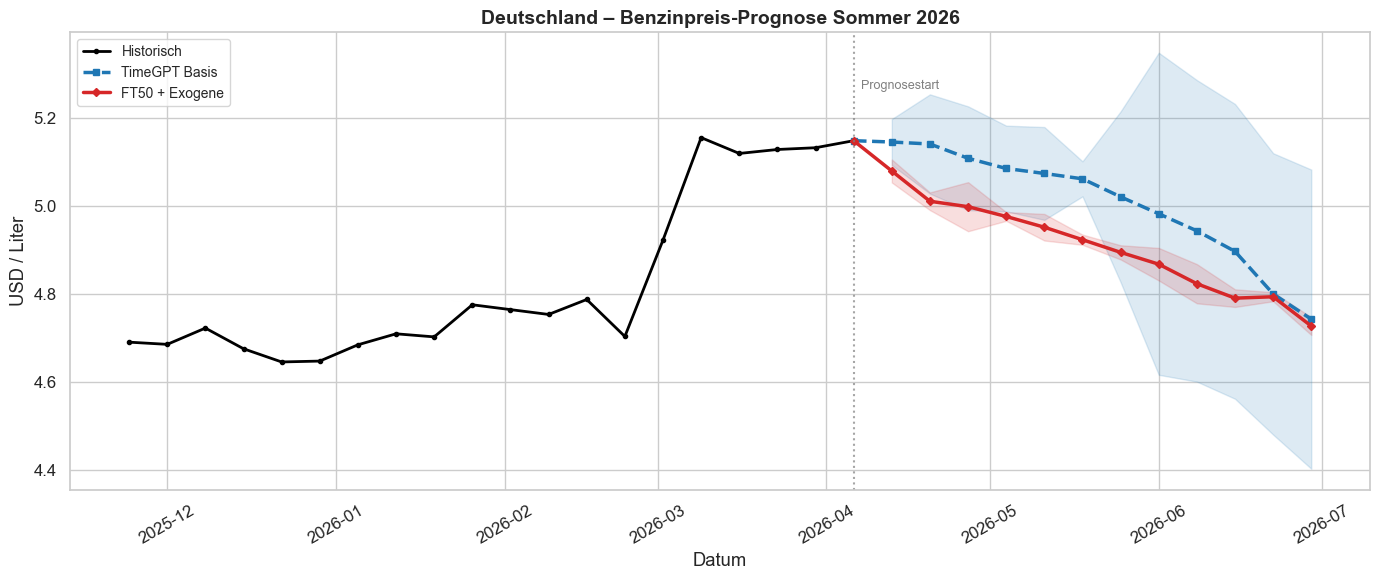

Deutschland:
  Basis:       5.145 → 4.742 USD/L
  FT50+Exog:   5.079 → 4.727 USD/L
  Differenz:   0.097 USD/L (Durchschnitt)



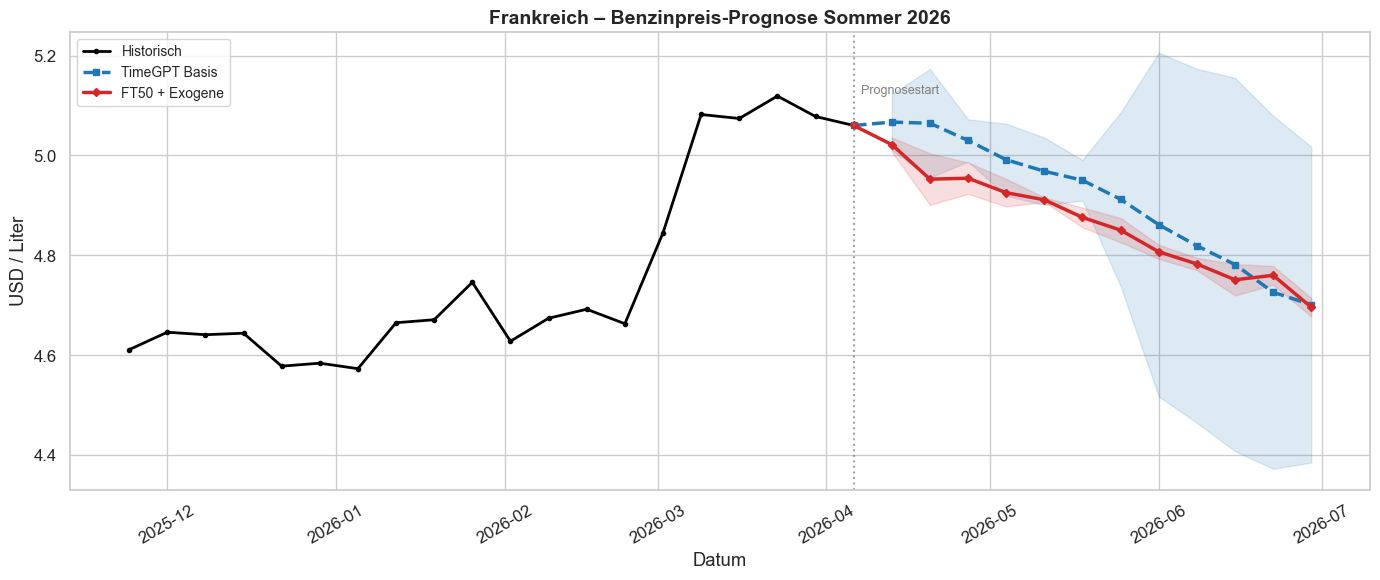

Frankreich:
  Basis:       5.067 → 4.701 USD/L
  FT50+Exog:   5.022 → 4.696 USD/L
  Differenz:   0.049 USD/L (Durchschnitt)



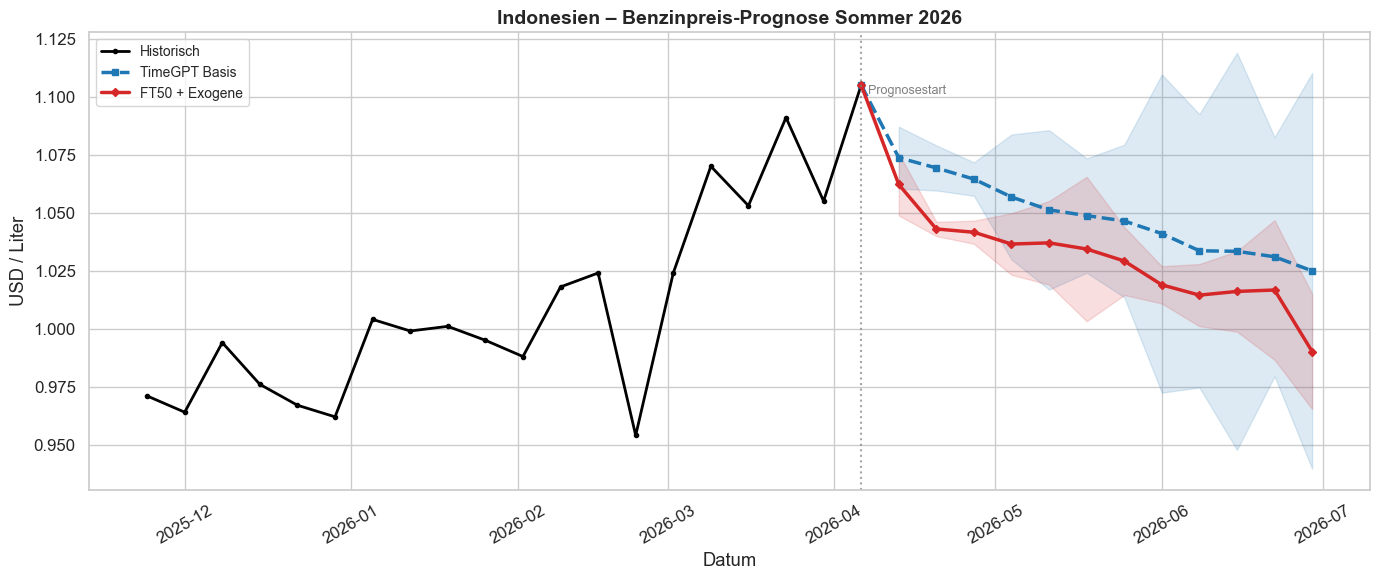

Indonesien:
  Basis:       1.074 → 1.025 USD/L
  FT50+Exog:   1.062 → 0.990 USD/L
  Differenz:   0.020 USD/L (Durchschnitt)



In [35]:
# ============================================================
# Visualisierung: 3 separate Grafiken (eine pro Land)
# ============================================================

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)

country_colors = {'Germany': '#1f77b4', 'France': '#ff7f0e', 'Indonesia': '#2ca02c'}

for country in COUNTRIES:
    fig, ax = plt.subplots(figsize=(14, 6))

    # Historische Daten (letzte 20 Wochen)
    hist = df_full[df_full['unique_id'] == country].tail(20)
    ax.plot(hist['ds'], hist['y'], color='black', linewidth=2, label='Historisch', marker='o', markersize=3)

    # Verbindungslinie zum Forecast
    last_hist_date = hist['ds'].iloc[-1]
    last_hist_val = hist['y'].iloc[-1]

    # Modell 1: Basis
    fb = fcst_business_basis[fcst_business_basis['unique_id'] == country]
    dates_basis = pd.concat([pd.Series([last_hist_date]), fb['ds']]).values
    vals_basis = np.concatenate([[last_hist_val], fb['TimeGPT'].values])
    ax.plot(dates_basis, vals_basis, color='#1f77b4', linewidth=2.5,
            linestyle='--', marker='s', markersize=4, label='TimeGPT Basis')
    ax.fill_between(fb['ds'].values, fb['TimeGPT-lo-80'].values,
                    fb['TimeGPT-hi-80'].values, alpha=0.15, color='#1f77b4')

    # Modell 2: FT50 + Exogene
    fe = fcst_business_ft_exog[fcst_business_ft_exog['unique_id'] == country]
    dates_ft = pd.concat([pd.Series([last_hist_date]), fe['ds']]).values
    vals_ft = np.concatenate([[last_hist_val], fe['TimeGPT'].values])
    ax.plot(dates_ft, vals_ft, color='#d62728', linewidth=2.5,
            marker='D', markersize=4, label='FT50 + Exogene')
    ax.fill_between(fe['ds'].values, fe['TimeGPT-lo-80'].values,
                    fe['TimeGPT-hi-80'].values, alpha=0.15, color='#d62728')

    # Vertikale Trennlinie
    ax.axvline(x=last_hist_date, color='gray', linestyle=':', alpha=0.7)
    ax.text(last_hist_date, ax.get_ylim()[1] * 0.98, '  Prognosestart',
            fontsize=9, color='gray', ha='left', va='top')

    ax.set_title(f'{COUNTRY_LABELS[country]} – Benzinpreis-Prognose Sommer 2026',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Datum')
    ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=10, loc='best')
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(BUSINESS_PLOT_DIR / f'business_forecast_{country.lower()}.png', dpi=150)
    plt.show()

    # Prognose-Zusammenfassung
    print(f'{COUNTRY_LABELS[country]}:')
    print(f'  Basis:       {fb["TimeGPT"].iloc[0]:.3f} → {fb["TimeGPT"].iloc[-1]:.3f} USD/L')
    print(f'  FT50+Exog:   {fe["TimeGPT"].iloc[0]:.3f} → {fe["TimeGPT"].iloc[-1]:.3f} USD/L')
    print(f'  Differenz:   {abs(fb["TimeGPT"].mean() - fe["TimeGPT"].mean()):.3f} USD/L (Durchschnitt)')
    print()

### Interpretation

**Was zeigen die Prognosen?**

Die beiden Modelle geben unterschiedliche Perspektiven:

- **TimeGPT Basis** extrapoliert rein aus den historischen Mustern – ohne Information über den Ölmarkt. Es erkennt Trends und Saisonalität, aber keine externen Schocks.

- **TimeGPT FT50 + Exogene** nutzt zusätzlich das Brent-Szenario (leichter Rückgang auf 120 USD), den projizierten Dieselpreis und die Steuerquote. Das Modell ist auf unsere Kraftstoff-Domäne feinabgestimmt.

**Wichtig:** Dies sind **keine Punktvorhersagen**, sondern **Szenarien**. Die Konfidenzintervalle zeigen die Unsicherheit. In der Praxis würde man mehrere Szenarien durchspielen (z.B. Brent bei 100, 120, 140 USD) und die Bandbreite der möglichen Benzinpreise bewerten.

**Für eine Geschäftsentscheidung** (z.B. Hedging, Budgetplanung, Preiskalkulation) liefert das FT50+Exogene-Modell die informiertere Prognose – vorausgesetzt, die Brent-Annahmen sind plausibel.

In [36]:
# ============================================================
# Exportierte Business-Forecast-Grafiken
# ============================================================

print('=== Business Scenario Forecasting – Exportierte Grafiken ===')
for f in sorted(BUSINESS_PLOT_DIR.glob('*.png')):
    print(f'  {f.name}')
print(f'\nInsgesamt: {len(list(BUSINESS_PLOT_DIR.glob("*.png")))} Grafiken in {BUSINESS_PLOT_DIR}')

=== Business Scenario Forecasting – Exportierte Grafiken ===
  business_forecast_france.png
  business_forecast_germany.png
  business_forecast_indonesia.png

Insgesamt: 3 Grafiken in ../docs/business_forecasts
